# Air Quality Index (AQI) Prediction System
### Next-Day AQI Forecasting using XGBoost | India Air Quality Dataset
---

In [1]:
# =============================================================
# Cell 1: Imports & Setup
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
import time
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

# ------ Global Style Configuration ------
TEAL_DARK   = '#0D9488'
TEAL_LIGHT  = '#14B8A6'
SLATE_DARK  = '#0F172A'
SLATE_MID   = '#1E293B'
AMBER       = '#F59E0B'
BG_COLOR    = '#F8FAFC'

plt.rcParams.update({
    'figure.facecolor': BG_COLOR,
    'axes.facecolor':   BG_COLOR,
    'axes.edgecolor':   SLATE_MID,
    'axes.labelcolor':  SLATE_DARK,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlecolor':  SLATE_DARK,
    'xtick.color':      SLATE_DARK,
    'ytick.color':      SLATE_DARK,
    'text.color':       SLATE_DARK,
    'grid.color':       '#CBD5E1',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
})

print('All libraries imported successfully.')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')
print(f'Sklearn : {__import__("sklearn").__version__}')
print(f'XGBoost : {__import__("xgboost").__version__}')

All libraries imported successfully.
Pandas  : 2.3.3
NumPy   : 2.2.6
Sklearn : 1.6.1
XGBoost : 3.1.1


---
## Step 2 — Data Loading & Initial Exploration

In [ ]:
# =============================================================
# Cell 2: Data Loading & Initial Exploration
# =============================================================

# Load the dataset
DATA_PATH = 'dataset/city_day.csv'
df_raw = pd.read_csv(DATA_PATH)

print('=' * 55)
print('  DATASET OVERVIEW')
print('=' * 55)
print(f'  Shape  : {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns')
print(f'  Cities : {df_raw["City"].nunique()}')

print('=' * 55)

# Basic schema
print('\n--- dtypes & non-null counts ---')
df_raw.info()

# First rows
print('\n--- First 5 rows ---')
display(df_raw.head())

# Descriptive statistics
print('\n--- Descriptive Statistics ---')
display(df_raw.describe().round(2))

# Missing values
print('\n--- Missing Values per Column ---')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

  DATASET OVERVIEW
  Shape  : 29,531 rows  x  16 columns
  Cities : 26
  Date range : 2015-01-01  →  2020-07-01

--- dtypes & non-null counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes:

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN



--- Descriptive Statistics ---


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.00,18391.00,25949.00,25946.00,25346.00,19203.00,27472.00,25677.00,25509.00,23908.00,21490.00,11422.00,24850.00
mean,67.45,118.13,17.57,28.56,32.31,23.48,2.25,14.53,34.49,3.28,8.70,3.07,166.46
std,64.66,90.61,22.79,24.47,31.65,25.68,6.96,18.13,21.69,15.81,19.97,6.32,140.70
min,0.04,0.01,0.02,0.01,0.00,0.01,0.00,0.01,0.01,0.00,0.00,0.00,13.00
25%,28.82,56.26,5.63,11.75,12.82,8.58,0.51,5.67,18.86,0.12,0.60,0.14,81.00
50%,48.57,95.68,9.89,21.69,23.52,15.85,0.89,9.16,30.84,1.07,2.97,0.98,118.00
75%,80.59,149.74,19.95,37.62,40.13,30.02,1.45,15.22,45.57,3.08,9.15,3.35,208.00
max,949.99,1000.00,390.68,362.21,467.63,352.89,175.81,193.86,257.73,455.03,454.85,170.37,2049.00



--- Missing Values per Column ---


,Missing Count,Missing %
Xylene,18109,61.32
PM10,11140,37.72
NH3,10328,34.97
Toluene,8041,27.23
Benzene,5623,19.04
AQI,4681,15.85
AQI_Bucket,4681,15.85
PM2.5,4598,15.57
NOx,4185,14.17
O3,4022,13.62


---
## Step 3 — Data Cleaning & Feature Engineering

In [3]:
# =============================================================
# Cell 3: Data Cleaning
# =============================================================

df = df_raw.copy()

# ── 3.1  Drop rows where AQI itself is missing (can't train on them) ──
before = len(df)
df.dropna(subset=['AQI'], inplace=True)
print(f'Dropped {before - len(df):,} rows with null AQI  →  {len(df):,} rows remain')

# ── 3.2  Median imputation of pollutant columns grouped by City ──
POLLUTANTS = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
              'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

def city_median_fill(group):
    """Fill NaN with city-level median; fallback to global median."""
    for col in POLLUTANTS:
        median_val = group[col].median()
        group[col] = group[col].fillna(median_val)
    return group

df = df.groupby('City', group_keys=False).apply(city_median_fill)

# Fallback: any remaining NaNs → global median
for col in POLLUTANTS:
    df[col].fillna(df[col].median(), inplace=True)

print(f'Remaining NaNs in pollutant columns: {df[POLLUTANTS].isnull().sum().sum()}')

# ── 3.3  Date parsing & temporal features ──
df['Date'] = pd.to_datetime(df['Date'])
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['DayOfWeek']  = df['Date'].dt.dayofweek     # 0=Monday … 6=Sunday

# ── 3.4  Create target: next-day AQI (shift by -1 within each city) ──
df.sort_values(['City', 'Date'], inplace=True)
df['AQI_Tomorrow'] = df.groupby('City')['AQI'].shift(-1)

# Drop the last record per city (no tomorrow known)
before = len(df)
df.dropna(subset=['AQI_Tomorrow'], inplace=True)
print(f'Dropped {before - len(df):,} rows with null AQI_Tomorrow  →  {len(df):,} rows remain')

df.reset_index(drop=True, inplace=True)

print('\n--- Cleaned DataFrame (first 5 rows) ---')
display(df[['City', 'Date', 'AQI', 'AQI_Tomorrow', 'Month', 'DayOfWeek']].head())
print(f'\nFinal dataset shape: {df.shape}')

Dropped 4,681 rows with null AQI  →  24,850 rows remain
Remaining NaNs in pollutant columns: 0
Dropped 26 rows with null AQI_Tomorrow  →  24,824 rows remain

--- Cleaned DataFrame (first 5 rows) ---


,City,Date,AQI,AQI_Tomorrow,Month,DayOfWeek
0,Ahmedabad,2015-01-29,209.0,328.0,1,3
1,Ahmedabad,2015-01-30,328.0,514.0,1,4
2,Ahmedabad,2015-01-31,514.0,782.0,1,5
3,Ahmedabad,2015-02-01,782.0,914.0,2,6
4,Ahmedabad,2015-02-02,914.0,660.0,2,0



Final dataset shape: (24824, 20)


---
## Step 4 — Exploratory Data Analysis

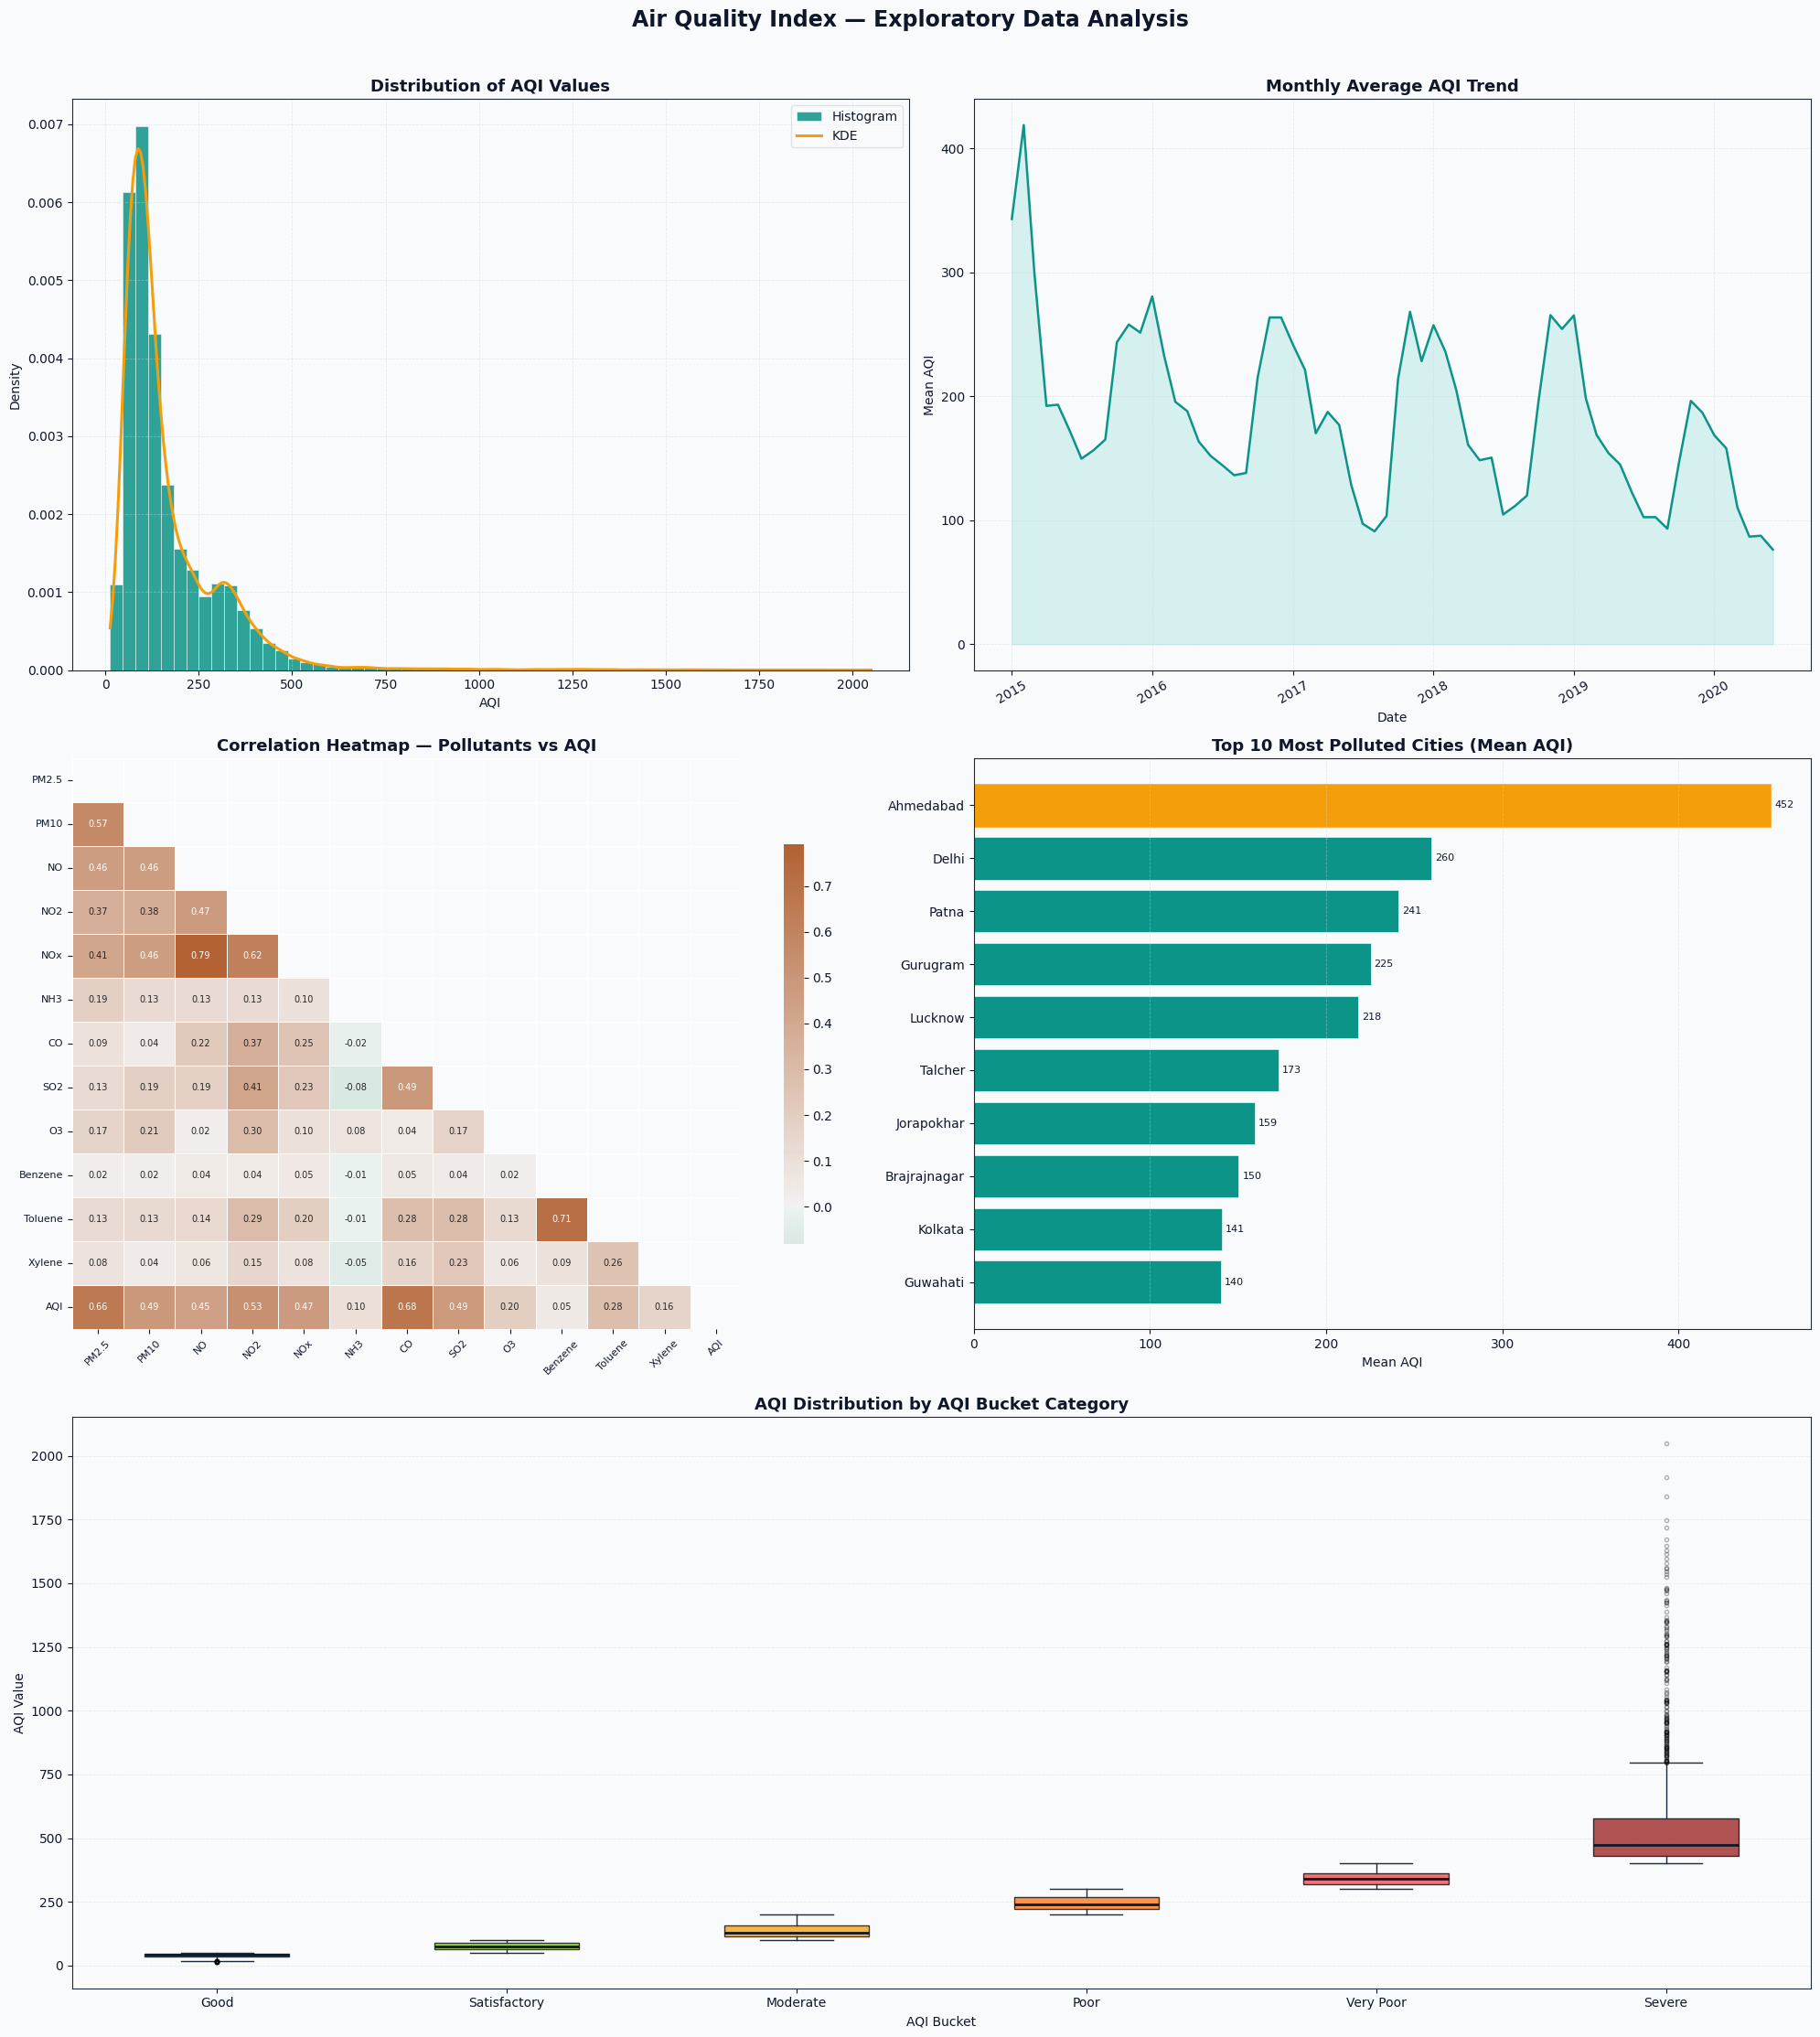

EDA plots saved to eda_plots.png


In [4]:
# =============================================================
# Cell 4: Exploratory Data Analysis (Visualizations)
# =============================================================

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Air Quality Index — Exploratory Data Analysis',
             fontsize=17, fontweight='bold', color=SLATE_DARK, y=1.01)

# ── Plot 1: AQI Distribution ──────────────────────────────────
ax1 = fig.add_subplot(3, 2, 1)
ax1.hist(df['AQI'], bins=60, color=TEAL_DARK, edgecolor='white',
         linewidth=0.4, alpha=0.85, density=True, label='Histogram')

# KDE overlay
from scipy.stats import gaussian_kde
kde_x = np.linspace(df['AQI'].min(), df['AQI'].max(), 300)
kde = gaussian_kde(df['AQI'].dropna())
ax1.plot(kde_x, kde(kde_x), color=AMBER, linewidth=2.2, label='KDE')
ax1.set_title('Distribution of AQI Values')
ax1.set_xlabel('AQI')
ax1.set_ylabel('Density')
ax1.legend(framealpha=0.5)
ax1.grid(True, alpha=0.4)

# ── Plot 2: AQI Trend Over Years (monthly average) ────────────
ax2 = fig.add_subplot(3, 2, 2)
monthly_avg = (df.groupby(['Year', 'Month'])['AQI']
                 .mean()
                 .reset_index())
monthly_avg['Period'] = pd.to_datetime(
    monthly_avg['Year'].astype(str) + '-' + monthly_avg['Month'].astype(str).str.zfill(2)
)
monthly_avg.sort_values('Period', inplace=True)

ax2.plot(monthly_avg['Period'], monthly_avg['AQI'],
         color=TEAL_DARK, linewidth=1.8)
ax2.fill_between(monthly_avg['Period'], monthly_avg['AQI'],
                 alpha=0.15, color=TEAL_LIGHT)
ax2.set_title('Monthly Average AQI Trend')
ax2.set_xlabel('Date')
ax2.set_ylabel('Mean AQI')
ax2.tick_params(axis='x', rotation=30)
ax2.grid(True, alpha=0.4)

# ── Plot 3: Correlation Heatmap ───────────────────────────────
ax3 = fig.add_subplot(3, 2, 3)
corr_cols = POLLUTANTS + ['AQI']
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle

cmap = sns.diverging_palette(160, 30, s=80, l=50, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.7},
            ax=ax3)
ax3.set_title('Correlation Heatmap — Pollutants vs AQI')
ax3.tick_params(axis='x', rotation=45, labelsize=8)
ax3.tick_params(axis='y', rotation=0,  labelsize=8)

# ── Plot 4: Top 10 Most Polluted Cities ───────────────────────
ax4 = fig.add_subplot(3, 2, 4)
top10 = (df.groupby('City')['AQI']
           .mean()
           .sort_values(ascending=False)
           .head(10))

bars = ax4.barh(top10.index[::-1], top10.values[::-1],
                color=TEAL_DARK, edgecolor='white', linewidth=0.4)
# Highlight top bar in amber
bars[-1].set_color(AMBER)

for bar, val in zip(bars, top10.values[::-1]):
    ax4.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
             f'{val:.0f}', va='center', fontsize=8, color=SLATE_DARK)

ax4.set_title('Top 10 Most Polluted Cities (Mean AQI)')
ax4.set_xlabel('Mean AQI')
ax4.grid(True, axis='x', alpha=0.4)

# ── Plot 5: AQI Boxplot by AQI_Bucket ────────────────────────
ax5 = fig.add_subplot(3, 1, 3)
bucket_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
bucket_colors = ['#22C55E', '#84CC16', '#F59E0B', '#F97316', '#EF4444', '#991B1B']

valid_buckets = [b for b in bucket_order if b in df['AQI_Bucket'].unique()]
df_bucket = df[df['AQI_Bucket'].isin(valid_buckets)]

bp = ax5.boxplot(
    [df_bucket[df_bucket['AQI_Bucket'] == b]['AQI'].values for b in valid_buckets],
    patch_artist=True,
    labels=valid_buckets,
    medianprops=dict(color=SLATE_DARK, linewidth=2),
    whiskerprops=dict(color=SLATE_MID),
    capprops=dict(color=SLATE_MID),
    flierprops=dict(marker='o', markersize=3, alpha=0.3, color=SLATE_MID)
)
for patch, color in zip(bp['boxes'], bucket_colors[:len(valid_buckets)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax5.set_title('AQI Distribution by AQI Bucket Category')
ax5.set_xlabel('AQI Bucket')
ax5.set_ylabel('AQI Value')
ax5.grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight',
            facecolor=BG_COLOR)
plt.show()
print('EDA plots saved to eda_plots.png')

---
## Step 5 — Feature Engineering & Train-Test Split

In [5]:
# =============================================================
# Cell 5: Feature Engineering & Train-Test Split
# =============================================================

FEATURES = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
    'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene',
    'Month', 'DayOfWeek'
]
TARGET = 'AQI_Tomorrow'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')
print(f'Target range         : [{y.min():.1f}, {y.max():.1f}]')
print(f'Target mean          : {y.mean():.1f}  |  std: {y.std():.1f}')

# ── 80 / 20 split — no shuffle to preserve temporal order ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)
print(f'\nTrain set : {len(X_train):,} samples')
print(f'Test  set : {len(X_test):,} samples')

# ── StandardScaler (fit on train only to avoid leakage) ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler for the inference pipeline
joblib.dump(scaler, 'scaler.pkl')
print('\nScaler saved → scaler.pkl')

# Save feature names for schema validation in prediction
joblib.dump(FEATURES, 'feature_names.pkl')
print('Feature names saved → feature_names.pkl')

Feature matrix shape : (24824, 14)
Target vector shape  : (24824,)
Target range         : [13.0, 2049.0]
Target mean          : 166.5  |  std: 140.7

Train set : 19,859 samples
Test  set : 4,965 samples

Scaler saved → scaler.pkl
Feature names saved → feature_names.pkl


---
## Step 6 — Model Training

In [ ]:
# =============================================================
# Cell 6: Model Training — XGBRegressor
# =============================================================

model = XGBRegressor(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
)

print('Training XGBoost model …')
t0 = time.time()

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

elapsed = time.time() - t0
print(f'Training complete in {elapsed:.2f} seconds.')
print(f'Total estimators trained : {model.n_estimators}')


Training XGBoost model …
Training complete in 0.79 seconds.
Total estimators trained : 500


---
## Step 7 — Model Evaluation & Visualizations

  MODEL PERFORMANCE ON TEST SET
  MAE   : 25.217
  RMSE  : 52.117
  R²    : 0.8570  (85.70% variance explained)
  MAPE  : 15.91%


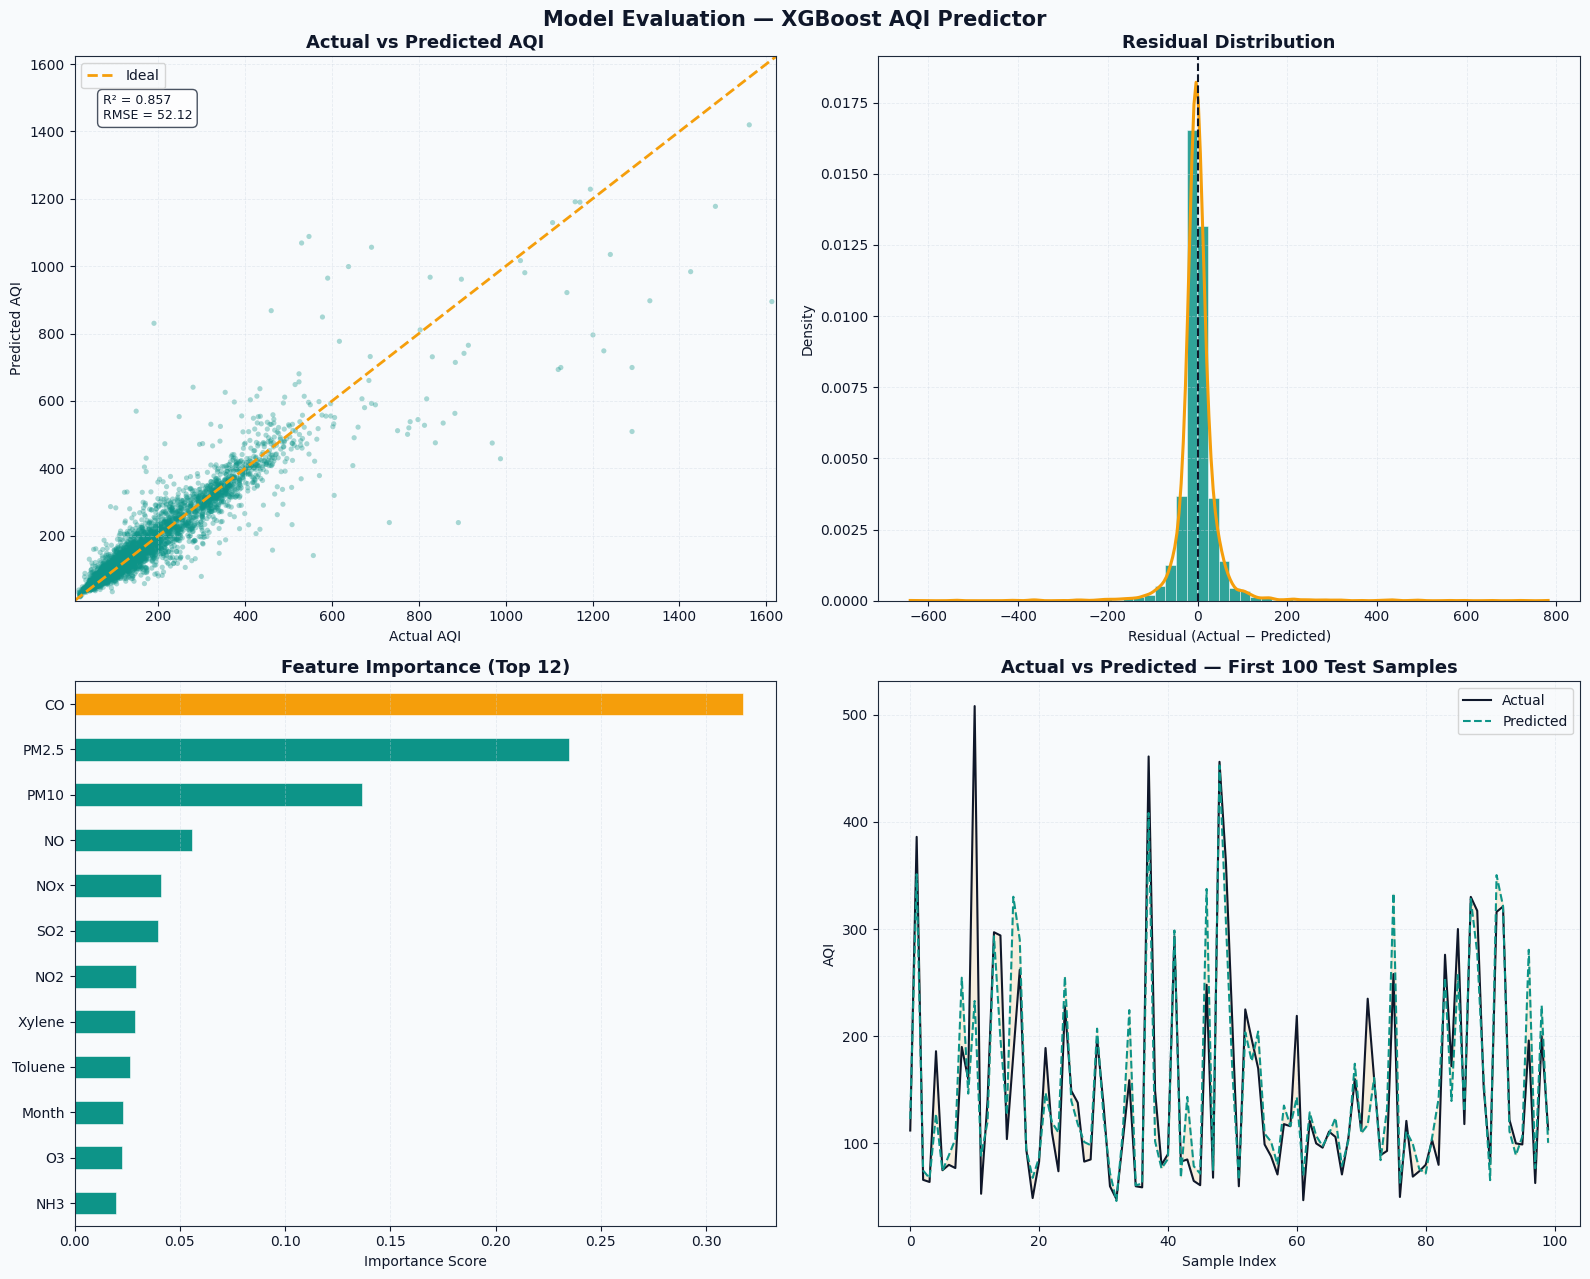

Evaluation plots saved to model_evaluation.png


In [ ]:
# =============================================================
# Cell 7: Model Evaluation & Visualizations
# =============================================================

y_pred = model.predict(X_test_scaled)

# ── Metrics ──────────────────────────────────────────────────
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# MAPE — guard against zero actuals
nonzero_mask = y_test.values != 0
mape = np.mean(np.abs((y_test.values[nonzero_mask] - y_pred[nonzero_mask])
                       / y_test.values[nonzero_mask])) * 100

print('=' * 45)
print('  MODEL PERFORMANCE ON TEST SET')
print('=' * 45)
print(f'  MAE   : {mae:.3f}')
print(f'  RMSE  : {rmse:.3f}')
print(f'  R²    : {r2:.4f}  ({r2*100:.2f}% variance explained)')

print('=' * 45)

# ── Residuals ────────────────────────────────────────────────
residuals = y_test.values - y_pred

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Model Evaluation — XGBoost AQI Predictor',
             fontsize=15, fontweight='bold', color=SLATE_DARK)

# ── Plot 1: Actual vs Predicted scatter ───────────────────────
ax = axes[0, 0]
ax.scatter(y_test, y_pred, alpha=0.35, s=14,
           color=TEAL_DARK, edgecolors='none')
lims = [min(y_test.min(), y_pred.min()) - 10,
        max(y_test.max(), y_pred.max()) + 10]
ax.plot(lims, lims, color=AMBER, linewidth=2, linestyle='--', label='Ideal')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title('Actual vs Predicted AQI')
ax.set_xlabel('Actual AQI')
ax.set_ylabel('Predicted AQI')
ax.legend()
ax.grid(True, alpha=0.4)
# Annotate metrics
ax.text(0.04, 0.93, f'R² = {r2:.3f}\nRMSE = {rmse:.2f}',
        transform=ax.transAxes, fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=SLATE_MID, alpha=0.8))

# ── Plot 2: Residual distribution ────────────────────────────
ax = axes[0, 1]
ax.hist(residuals, bins=60, color=TEAL_DARK, edgecolor='white',
        linewidth=0.4, alpha=0.85, density=True)
kde_r = gaussian_kde(residuals)
rx = np.linspace(residuals.min(), residuals.max(), 300)
ax.plot(rx, kde_r(rx), color=AMBER, linewidth=2.2)
ax.axvline(0, color=SLATE_DARK, linewidth=1.5, linestyle='--')
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual (Actual − Predicted)')
ax.set_ylabel('Density')
ax.grid(True, alpha=0.4)

# ── Plot 3: Feature Importance (top 12) ──────────────────────
ax = axes[1, 0]
importances = pd.Series(model.feature_importances_, index=FEATURES)
top12 = importances.sort_values(ascending=True).tail(12)

colors = [AMBER if i == len(top12) - 1 else TEAL_DARK
          for i in range(len(top12))]
top12.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.4)
ax.set_title('Feature Importance (Top 12)')
ax.set_xlabel('Importance Score')
ax.grid(True, axis='x', alpha=0.4)

# ── Plot 4: Actual vs Predicted — first 100 test samples ─────
ax = axes[1, 1]
n = 100
ax.plot(range(n), y_test.values[:n], color=SLATE_DARK,
        linewidth=1.5, label='Actual', zorder=2)
ax.plot(range(n), y_pred[:n], color=TEAL_DARK,
        linewidth=1.5, linestyle='--', label='Predicted', zorder=3)
ax.fill_between(range(n), y_test.values[:n], y_pred[:n],
                alpha=0.12, color=AMBER)
ax.set_title('Actual vs Predicted — First 100 Test Samples')
ax.set_xlabel('Sample Index')
ax.set_ylabel('AQI')
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight',
            facecolor=BG_COLOR)
plt.show()
print('Evaluation plots saved to model_evaluation.png')

---
## Step 8 — AQI Category Classification

In [8]:
# =============================================================
# Cell 8: AQI Category Classification Function
# =============================================================

def get_aqi_category(aqi_value: float) -> dict:
    """
    Map a numeric AQI value to its category, colour code, and
    associated health advice.

    Parameters
    ----------
    aqi_value : float
        Predicted or measured AQI.

    Returns
    -------
    dict with keys: category, color, advice
    """
    aqi = float(aqi_value)

    if aqi <= 50:
        return {
            'category': 'Good',
            'color':    '#22C55E',
            'advice':   'Air quality is satisfactory. No restrictions.'
        }
    elif aqi <= 100:
        return {
            'category': 'Satisfactory',
            'color':    '#84CC16',
            'advice':   'Air quality is acceptable. Unusually sensitive people should consider reducing prolonged outdoor exertion.'
        }
    elif aqi <= 200:
        return {
            'category': 'Moderate',
            'color':    '#F59E0B',
            'advice':   'Members of sensitive groups may experience health effects. General public less likely to be affected.'
        }
    elif aqi <= 300:
        return {
            'category': 'Poor',
            'color':    '#F97316',
            'advice':   'Everyone may begin to experience health effects. Sensitive groups should avoid outdoor activity.'
        }
    elif aqi <= 400:
        return {
            'category': 'Very Poor',
            'color':    '#EF4444',
            'advice':   'Health warnings of emergency conditions. The entire population is likely to be affected. Avoid outdoor activity.'
        }
    elif aqi <= 500:
        return {
            'category': 'Severe',
            'color':    '#991B1B',
            'advice':   'Serious health effects. Avoid all outdoor exertion. Keep windows closed and use air purifiers indoors.'
        }
    else:
        return {
            'category': 'Hazardous',
            'color':    '#581C87',
            'advice':   'Emergency conditions. Everyone should avoid all outdoor activity. Seek medical advice if symptoms appear.'
        }


# ── Quick sanity check across the AQI scale ──────────────────
print('AQI Category Look-up Table')
print('-' * 62)
for test_val in [25, 75, 150, 250, 350, 450, 550]:
    info = get_aqi_category(test_val)
    print(f'  AQI {test_val:>4}  →  {info["category"]:<13}  {info["color"]}')
print('-' * 62)

AQI Category Look-up Table
--------------------------------------------------------------
  AQI   25  →  Good           #22C55E
  AQI   75  →  Satisfactory   #84CC16
  AQI  150  →  Moderate       #F59E0B
  AQI  250  →  Poor           #F97316
  AQI  350  →  Very Poor      #EF4444
  AQI  450  →  Severe         #991B1B
  AQI  550  →  Hazardous      #581C87
--------------------------------------------------------------


---
## Step 9 — Save Model & Artifacts

In [9]:
# =============================================================
# Cell 9: Save Model & Artifacts
# =============================================================

MODEL_PATH        = 'aqi_model.pkl'
SCALER_PATH       = 'scaler.pkl'         # already saved in Cell 5
FEATURES_PATH     = 'feature_names.pkl'  # already saved in Cell 5

# Save XGBoost model
joblib.dump(model, MODEL_PATH)

# Helper to format file sizes
def _size(path: str) -> str:
    size_bytes = os.path.getsize(path)
    if size_bytes >= 1_048_576:
        return f'{size_bytes / 1_048_576:.2f} MB'
    return f'{size_bytes / 1_024:.1f} KB'

print('Artifacts saved successfully:')
print(f'  {MODEL_PATH:<22} {_size(MODEL_PATH)}')
print(f'  {SCALER_PATH:<22} {_size(SCALER_PATH)}')
print(f'  {FEATURES_PATH:<22} {_size(FEATURES_PATH)}')
print('\nAll artifacts ready for deployment.')

Artifacts saved successfully:
  aqi_model.pkl          2.07 MB
  scaler.pkl             1.3 KB
  feature_names.pkl      0.1 KB

All artifacts ready for deployment.


---
## Step 10 — Test Prediction Pipeline

Artifacts loaded successfully.

  NEXT-DAY AQI PREDICTION RESULT
  Predicted AQI : 185.7
  Category      : Moderate
  Color Code    : #F59E0B
  Health Advice : People with respiratory issues should limit outdoor exposure.

Predicted AQI: 185.7 | Category: Moderate | Health Advice: People with respiratory issues should limit outdoor exposure.


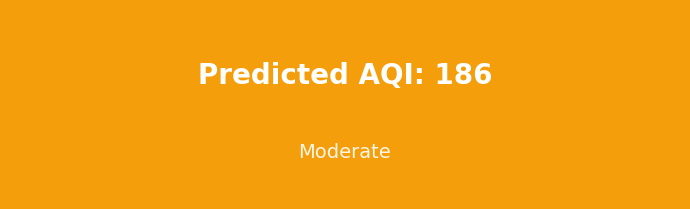

In [10]:
# =============================================================
# Cell 10: Test Prediction Pipeline
# =============================================================
# Simulates a real-time inference call using WAQI-style sensor data.

# ── 10.1  Load saved artifacts ────────────────────────────────
loaded_model    = joblib.load('aqi_model.pkl')
loaded_scaler   = joblib.load('scaler.pkl')
loaded_features = joblib.load('feature_names.pkl')
print('Artifacts loaded successfully.\n')

# ── 10.2  Sample input — mimics a WAQI API payload ───────────
#          (values typical for a moderately polluted Indian city)
sample_input = {
    'PM2.5':     85.4,   # μg/m³
    'PM10':     142.7,   # μg/m³
    'NO':         8.3,   # μg/m³
    'NO2':       32.1,   # μg/m³
    'NOx':       40.6,   # ppb
    'NH3':       15.2,   # μg/m³
    'CO':         1.1,   # mg/m³
    'SO2':       12.5,   # μg/m³
    'O3':        38.9,   # μg/m³
    'Benzene':    2.4,   # μg/m³
    'Toluene':    8.7,   # μg/m³
    'Xylene':     1.9,   # μg/m³
    'Month':      11,    # November
    'DayOfWeek':   2,    # Wednesday
}

# ── 10.3  Build input DataFrame (schema matches training) ─────
input_df = pd.DataFrame([sample_input])[loaded_features]

# ── 10.4  Scale → Predict ─────────────────────────────────────
input_scaled  = loaded_scaler.transform(input_df)
predicted_aqi = float(loaded_model.predict(input_scaled)[0])
predicted_aqi = max(0.0, predicted_aqi)   # AQI cannot be negative

# ── 10.5  Categorise & report ─────────────────────────────────
info = get_aqi_category(predicted_aqi)

health_map = {
    'Good':         'No special precautions needed.',
    'Satisfactory': 'Sensitive individuals should reduce prolonged outdoor activity.',
    'Moderate':     'People with respiratory issues should limit outdoor exposure.',
    'Poor':         'Wear N95 mask outdoors. Avoid strenuous activities.',
    'Very Poor':    'Stay indoors. Use air purifiers. Seek medical advice if unwell.',
    'Severe':       'Do not go outdoors. All residents should reduce outdoor activity.',
    'Hazardous':    'Emergency situation. Evacuate if possible. Seek immediate medical attention.',
}
advice = health_map.get(info['category'], info['advice'])

print('=' * 65)
print('  NEXT-DAY AQI PREDICTION RESULT')
print('=' * 65)
print(f'  Predicted AQI : {predicted_aqi:.1f}')
print(f'  Category      : {info["category"]}')
print(f'  Color Code    : {info["color"]}')
print(f'  Health Advice : {advice}')
print('=' * 65)
print(f'\nPredicted AQI: {predicted_aqi:.1f} | Category: {info["category"]} | Health Advice: {advice}')

# ── 10.6  Visual badge ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 2.2))
fig.patch.set_facecolor(info['color'])
ax.set_facecolor(info['color'])
ax.axis('off')
ax.text(0.5, 0.65, f'Predicted AQI: {predicted_aqi:.0f}',
        ha='center', va='center', fontsize=20, fontweight='bold',
        color='white', transform=ax.transAxes)
ax.text(0.5, 0.25, info['category'],
        ha='center', va='center', fontsize=14,
        color='white', alpha=0.9, transform=ax.transAxes)
plt.tight_layout()
plt.show()